In [58]:
# Anomaly Detection Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# Load dataset from Kaggle
df = pd.read_csv("Finance_data.csv")
print(df.head())

   gender  age Investment_Avenues  Mutual_Funds  Equity_Market  Debentures  \
0  Female   34                Yes             1              2           5   
1  Female   23                Yes             4              3           2   
2    Male   30                Yes             3              6           4   
3    Male   22                Yes             2              1           3   
4  Female   24                 No             2              1           3   

   Government_Bonds  Fixed_Deposits  PPF  Gold  ...           Duration  \
0                 3               7    6     4  ...          1-3 years   
1                 1               5    6     7  ...  More than 5 years   
2                 2               5    1     7  ...          3-5 years   
3                 7               6    4     5  ...   Less than 1 year   
4                 6               4    5     7  ...   Less than 1 year   

  Invest_Monitor   Expect       Avenue What are your savings objectives?  \
0        M

In [59]:
df.shape   # Check structure

(40, 24)

In [60]:
df.columns    # Column names

Index(['gender', 'age', 'Investment_Avenues', 'Mutual_Funds', 'Equity_Market',
       'Debentures', 'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold',
       'Stock_Marktet', 'Factor', 'Objective', 'Purpose', 'Duration',
       'Invest_Monitor', 'Expect', 'Avenue',
       'What are your savings objectives?', 'Reason_Equity', 'Reason_Mutual',
       'Reason_Bonds', 'Reason_FD', 'Source'],
      dtype='str')

In [61]:
df.info()   # Data types

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   gender                             40 non-null     str  
 1   age                                40 non-null     int64
 2   Investment_Avenues                 40 non-null     str  
 3   Mutual_Funds                       40 non-null     int64
 4   Equity_Market                      40 non-null     int64
 5   Debentures                         40 non-null     int64
 6   Government_Bonds                   40 non-null     int64
 7   Fixed_Deposits                     40 non-null     int64
 8   PPF                                40 non-null     int64
 9   Gold                               40 non-null     int64
 10  Stock_Marktet                      40 non-null     str  
 11  Factor                             40 non-null     str  
 12  Objective                          

In [62]:
df.describe()   # To recognize unusual values

,age,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,27.800000,2.550000,3.475000,5.750000,4.650000,3.575000,2.025000,5.975000
std,3.560467,1.197219,1.131994,1.675617,1.369072,1.795828,1.609069,1.143263
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,25.750000,2.000000,3.000000,5.000000,4.000000,2.750000,1.000000,6.000000
50%,27.000000,2.000000,4.000000,6.500000,5.000000,3.500000,1.000000,6.000000
75%,30.000000,3.000000,4.000000,7.000000,5.000000,5.000000,2.250000,7.000000
max,35.000000,7.000000,6.000000,7.000000,7.000000,7.000000,6.000000,7.000000


In [11]:
# Remove non-numeric columns (IDs, timestamps, etc.)
X = df.select_dtypes(include=["float64", "int64"])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X.shape)

(40, 8)


In [13]:
# Train the Isolation Forest model: isolates data points by randomly splitting the data to find unusual, rare data points.
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X_scaled)
prediction = model.predict(X_scaled)

In [14]:
# Add prediction column to dataframe
df["anomaly"] = prediction

# Count the number of anomalies
df["anomaly"].value_counts()

anomaly
 1    38
-1     2
Name: count, dtype: int64

In [15]:
# Check detected anomalies
anomalies = df[df["anomaly"] == -1]
anomalies.head()

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source,anomaly
0,Female,34,Yes,1,2,5,3,7,6,4,...,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines,-1
5,Female,24,No,7,5,4,6,3,1,2,...,Daily,30%-40%,Mutual Fund,Retirement Plan,Liquidity,Fund Diversification,Safe Investment,Risk Free,Internet,-1


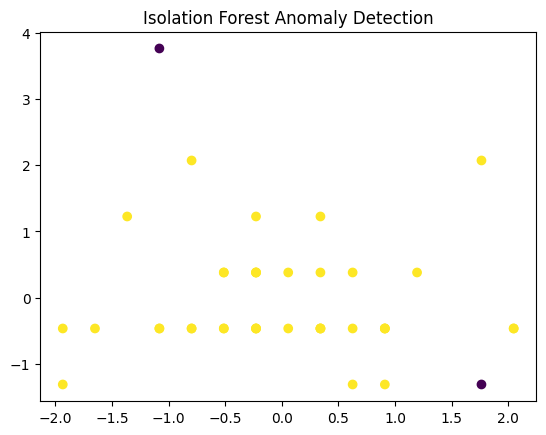

In [16]:
# Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=prediction)
plt.title("Isolation Forest Anomaly Detection")
plt.show()

In [17]:
# Local Outlier Factor model: detects anomalies by comparing the density of a point to the density of its neighbors.
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_prediction = lof.fit_predict(X_scaled)

In [18]:
df["lof_anomaly"] = lof_prediction

In [19]:
df["lof_anomaly"].value_counts()

lof_anomaly
 1    38
-1     2
Name: count, dtype: int64

In [20]:
# View anomalies
lof_anomalies = df[df["lof_anomaly"] == -1]
lof_anomalies.head()

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source,anomaly,lof_anomaly
0,Female,34,Yes,1,2,5,3,7,6,4,...,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines,-1,-1
5,Female,24,No,7,5,4,6,3,1,2,...,30%-40%,Mutual Fund,Retirement Plan,Liquidity,Fund Diversification,Safe Investment,Risk Free,Internet,-1,-1


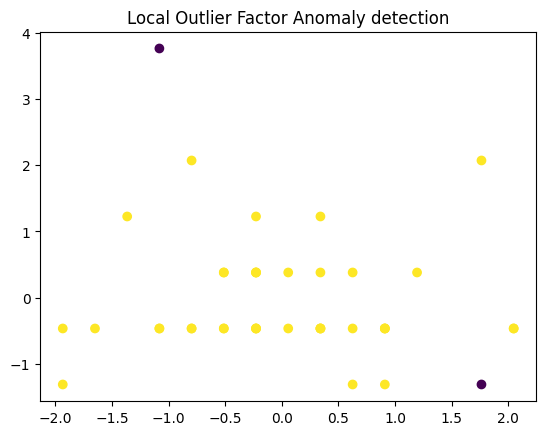

In [21]:
# Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df["lof_anomaly"])
plt.title("Local Outlier Factor Anomaly detection")
plt.show()

In [22]:
# One-class SVM (Support Vector Machine) model: learns the boundary around normal data. Anything outside the boundary = anomaly.
from sklearn.svm import OneClassSVM
svm = OneClassSVM(nu=0.05)
svm_prediction = svm.fit_predict(X_scaled)
df["svm_anomaly"] = svm_prediction

In [23]:
# Value count
df["svm_anomaly"].value_counts()

svm_anomaly
 1    30
-1    10
Name: count, dtype: int64

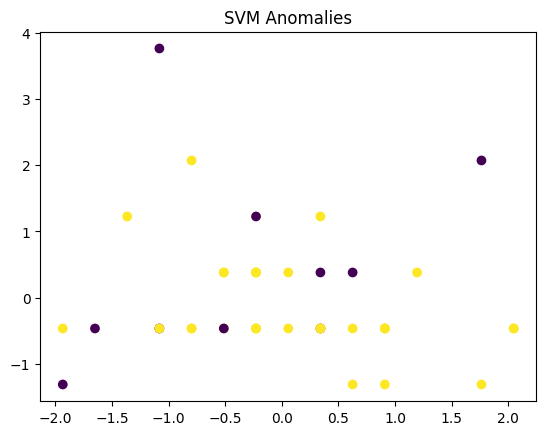

In [24]:
# Visual of SVM anomalies
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df["svm_anomaly"])
plt.title("SVM Anomalies")
plt.show()

In [26]:
# Score evaluation for Isolation Forest Model
# Higher value = normal point; Lower value = anomaly 

df["iforest_score"] = model.decision_function(X_scaled)  

In [27]:
df.sort_values("iforest_score").head()

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source,anomaly,lof_anomaly,svm_anomaly,iforest_score
0,Female,34,Yes,1,2,5,3,7,6,4,...,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines,-1,-1,1,-0.030023
5,Female,24,No,7,5,4,6,3,1,2,...,Retirement Plan,Liquidity,Fund Diversification,Safe Investment,Risk Free,Internet,-1,-1,-1,-0.018312
3,Male,22,Yes,2,1,3,7,6,4,5,...,Retirement Plan,Dividend,Fund Diversification,Tax Incentives,High Interest Rates,Internet,1,1,-1,0.000964
30,Male,27,Yes,4,5,1,2,7,3,6,...,Education,Capital Appreciation,Tax Benefits,Safe Investment,Fixed Returns,Television,1,1,-1,0.018938
1,Female,23,Yes,4,3,2,1,5,6,7,...,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants,1,1,1,0.020922


In [28]:
# Score evaluation for Local Outlier Factor
# Close to -1 = normal; much smaller = anomaly

df["lof_score"] = lof.negative_outlier_factor_

In [29]:
df.sort_values("lof_score").head()

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source,anomaly,lof_anomaly,svm_anomaly,iforest_score,lof_score
5,Female,24,No,7,5,4,6,3,1,2,...,Liquidity,Fund Diversification,Safe Investment,Risk Free,Internet,-1,-1,-1,-0.018312,-1.955302
0,Female,34,Yes,1,2,5,3,7,6,4,...,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines,-1,-1,1,-0.030023,-1.646047
30,Male,27,Yes,4,5,1,2,7,3,6,...,Capital Appreciation,Tax Benefits,Safe Investment,Fixed Returns,Television,1,1,-1,0.018938,-1.644494
29,Female,34,Yes,5,4,3,2,7,1,6,...,Capital Appreciation,Tax Benefits,Safe Investment,Fixed Returns,Newspapers and Magazines,1,1,-1,0.026559,-1.581643
1,Female,23,Yes,4,3,2,1,5,6,7,...,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants,1,1,1,0.020922,-1.546121


In [30]:
# Score evaluation for one-class SMV
# Positive = normal, negative = anomaly

df["svm_score"] = svm.decision_function(X_scaled)

In [31]:
df.sort_values("svm_score").head()

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Reason_Mutual,Reason_Bonds,Reason_FD,Source,anomaly,lof_anomaly,svm_anomaly,iforest_score,lof_score,svm_score
12,Female,21,No,1,2,3,4,5,6,7,...,Better Returns,Safe Investment,Risk Free,Internet,1,1,-1,0.044379,-1.495301,-0.000504
18,Male,29,Yes,3,2,7,4,5,1,6,...,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines,1,1,-1,0.186124,-1.025235,-0.000424
33,Male,26,Yes,2,3,6,4,1,5,7,...,Better Returns,Safe Investment,Risk Free,Newspapers and Magazines,1,1,-1,0.118177,-1.143992,-0.000283
5,Female,24,No,7,5,4,6,3,1,2,...,Fund Diversification,Safe Investment,Risk Free,Internet,-1,-1,-1,-0.018312,-1.955302,-0.000277
2,Male,30,Yes,3,6,4,2,5,1,7,...,Tax Benefits,Assured Returns,Fixed Returns,Television,1,1,-1,0.085110,-1.395842,-0.000242


In [32]:
# Compare all scores
df[["iforest_score","lof_score","svm_score"]].head()

,iforest_score,lof_score,svm_score
0,-0.030023,-1.646047,0.000392
1,0.020922,-1.546121,0.000169
2,0.085110,-1.395842,-0.000242
3,0.000964,-1.507564,-0.000110
4,0.041799,-1.429255,-0.000207


In [33]:
# Find strongest anomalies across all 3 models
# let's use 10 examples

df.sort_values("iforest_score").head(10)

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Reason_Mutual,Reason_Bonds,Reason_FD,Source,anomaly,lof_anomaly,svm_anomaly,iforest_score,lof_score,svm_score
0,Female,34,Yes,1,2,5,3,7,6,4,...,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines,-1,-1,1,-0.030023,-1.646047,0.000392
5,Female,24,No,7,5,4,6,3,1,2,...,Fund Diversification,Safe Investment,Risk Free,Internet,-1,-1,-1,-0.018312,-1.955302,-0.000277
3,Male,22,Yes,2,1,3,7,6,4,5,...,Fund Diversification,Tax Incentives,High Interest Rates,Internet,1,1,-1,0.000964,-1.507564,-0.000110
30,Male,27,Yes,4,5,1,2,7,3,6,...,Tax Benefits,Safe Investment,Fixed Returns,Television,1,1,-1,0.018938,-1.644494,-0.000047
1,Female,23,Yes,4,3,2,1,5,6,7,...,Better Returns,Safe Investment,High Interest Rates,Financial Consultants,1,1,1,0.020922,-1.546121,0.000169
29,Female,34,Yes,5,4,3,2,7,1,6,...,Tax Benefits,Safe Investment,Fixed Returns,Newspapers and Magazines,1,1,-1,0.026559,-1.581643,-0.000139
37,Male,25,Yes,5,4,7,6,1,2,3,...,Better Returns,Safe Investment,Fixed Returns,Financial Consultants,1,1,1,0.037300,-1.456890,0.000368
4,Female,24,No,2,1,3,6,4,5,7,...,Better Returns,Safe Investment,Risk Free,Internet,1,1,-1,0.041799,-1.429255,-0.000207
12,Female,21,No,1,2,3,4,5,6,7,...,Better Returns,Safe Investment,Risk Free,Internet,1,1,-1,0.044379,-1.495301,-0.000504
2,Male,30,Yes,3,6,4,2,5,1,7,...,Tax Benefits,Assured Returns,Fixed Returns,Television,1,1,-1,0.085110,-1.395842,-0.000242


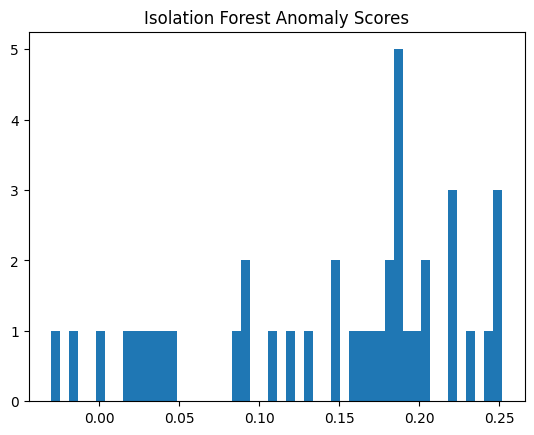

In [37]:
# Histograms of scores

plt.hist(df["iforest_score"], bins=50)
plt.title("Isolation Forest Anomaly Scores")
plt.show()

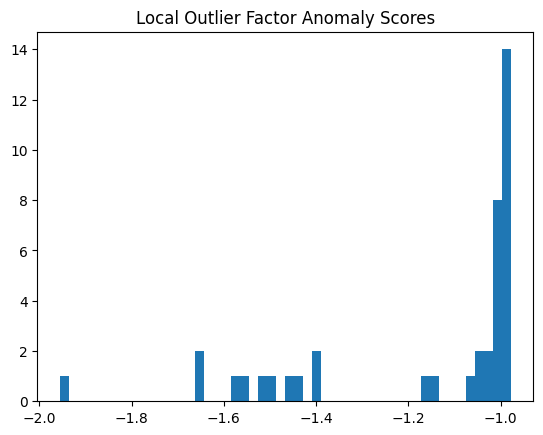

In [38]:
plt.hist(df["lof_score"], bins=50)
plt.title("Local Outlier Factor Anomaly Scores")
plt.show()

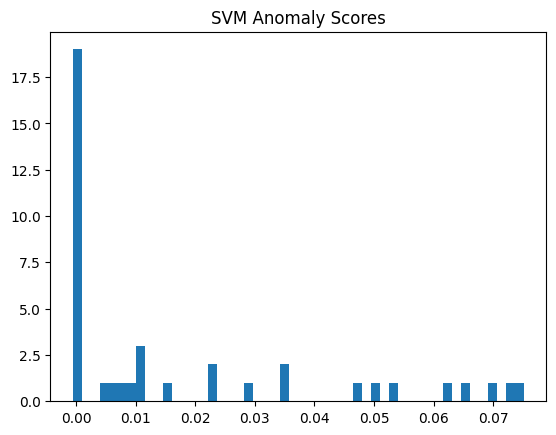

In [39]:
plt.hist(df["svm_score"], bins=50)
plt.title("SVM Anomaly Scores")
plt.show()